# Build a Small Language Model From Scratch

This notebook builds a **~27M parameter** language model from a **random initialization** and trains it on TinyStories using free Colab hardware.

### What's inside

| Part | What we'll be building |
|---|---|
| **Part 1** | Load, inspect, and clean the TinyStories dataset |
| **Part 2** | Pack the corpus into fixed-length blocks |
| **Part 3** | Build the Transformer — RMSNorm, RoPE, GQA, SwiGLU |
| **Part 4** | Write the training loop — AMP, grad accumulation, cosine LR, checkpointing |
| **Part 5** | Profile GPU memory, survive Colab disconnects |
| **Part 6** | Evaluate — loss curves, perplexity, sampling strategies, KV-cache generation |


## The architecture we're building

We're using the architecture template that Llama 3, Mistral, Qwen 3 and Gemma all converged on:

| Component | Legacy (GPT-2, 2019) | **What we use (2026)** |
|---|---|---|
| Normalization | LayerNorm | **RMSNorm** (pre-norm) |
| Positional encoding | Learned absolute | **RoPE** (rotary) |
| FFN activation | GELU | **SwiGLU** |
| Attention | Multi-Head (MHA) | **Grouped-Query (GQA)** |
| Linear biases | Yes | **No biases** |
| Embeddings | Untied | **Tied** (input = output) |
| Attention kernel | Manual softmax | **Flash Attention** via `attn_implementation="sdpa"` |
| Generation | Recompute everything | **KV cache** |

Every weight is trained from a random initialization `LlamaForCausalLM(config)`, not `.from_pretrained()`. Nothing is downloaded. The architecture comes from the library; the model is entirely yours.

### Part 0 — Environment Setup

In [1]:
# 0.1 — Confirm the GPU.
import subprocess
try:
    print(subprocess.check_output(["nvidia-smi"]).decode())
except Exception:
    print("No GPU. Runtime -> Change runtime type -> T4 GPU -> Save, then restart.")

Thu Aug  6 22:20:44 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA A100-SXM4-40GB          Off |   00000000:00:04.0 Off |                    0 |
| N/A   36C    P0             48W /  400W |       0MiB /  40960MiB |      0%      Default |
|                                         |                        |             Disabled |
+-----------------------------------------+-----

In [2]:
# 0.2 — Install. Versions are pinned deliberately: transformers v5 ships
# breaking changes weekly, so an unpinned install WILL eventually break this notebook.

!pip install -q "transformers>=5.0,<6.0" "datasets>=4.0.0" "tokenizers>=0.22.0" "accelerate>=1.1.0" "huggingface_hub>=1.0.0" tqdm matplotlib

import transformers, tokenizers, datasets, torch
print(f"transformers : {transformers.__version__}")
print(f"datasets     : {datasets.__version__}")
print(f"tokenizers   : {tokenizers.__version__}")
print(f"torch        : {torch.__version__}")

transformers : 5.13.1
datasets     : 4.0.0
tokenizers   : 0.22.2
torch        : 2.11.0+cu128


In [3]:
# 0.3 — Imports, seed, device, precision.

import os, math, json, time, random, itertools
import numpy as np
import torch
import matplotlib.pyplot as plt

from transformers import set_seed

SEED = 1337
set_seed(SEED)   # seeds python, numpy and torch in one call

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

# T4 (Turing) does NOT support bfloat16. Ampere+ (A100, L4) does.
USE_BF16 = DEVICE == "cuda" and torch.cuda.is_bf16_supported()
USE_FP16 = DEVICE == "cuda" and not USE_BF16

print(f"Device : {DEVICE}")
if DEVICE == "cuda":
    p = torch.cuda.get_device_properties(0)
    print(f"GPU    : {p.name} ({p.total_memory/1e9:.1f} GB, sm_{p.major}{p.minor})")
print(f"Precision -> bf16={USE_BF16}  fp16={USE_FP16}")

Device : cuda
GPU    : NVIDIA A100-SXM4-40GB (42.4 GB, sm_80)
Precision -> bf16=True  fp16=False


In [4]:
# 0.4 — Mount Drive. Everything persists here so a disconnect costs you nothing.

try:
    from google.colab import drive
    drive.mount("/content/drive")
    PROJECT_DIR = "/content/drive/MyDrive/my_slm_hf"
except ImportError:
    PROJECT_DIR = "./my_slm_hf"

TOKENIZER_DIR = os.path.join(PROJECT_DIR, "tokenizer")
CKPT_DIR      = os.path.join(PROJECT_DIR, "checkpoints")
FINAL_DIR     = os.path.join(PROJECT_DIR, "final_model")
for d in (PROJECT_DIR, TOKENIZER_DIR, CKPT_DIR, FINAL_DIR):
    os.makedirs(d, exist_ok=True)

print(f"Project     : {PROJECT_DIR}")
print(f"Checkpoints : {CKPT_DIR}")

Mounted at /content/drive
Project     : /content/drive/MyDrive/my_slm_hf
Checkpoints : /content/drive/MyDrive/my_slm_hf/checkpoints


---
# Part 1 - Choosing and Preparing Your Dataset

## Why TinyStories

A 27M parameter model does not have the capacity to learn the full distribution of internet English. Point it at a giant web scrape and it will spread itself thin and learn nothing well.

[TinyStories](https://huggingface.co/datasets/roneneldan/TinyStories) (Eldan & Li, 2023) is ~2.1M synthetic short stories restricted to vocabulary a 3–4 year old would understand. The paper's finding: models as small as 10M parameters trained on it produce grammatical, coherent English with a real narrative arc. Narrow clean data + small model = a result worth showing people.

| Mode | Stories | T4 time |
|---|---|---|
| **Quick** (`USE_SUBSET=True`) | 300,000 | ~45 min |
| **Full** (`USE_SUBSET=False`) | 2,100,000 | ~4 hours |

Set USE_SUBSET = True for a fast first pass. The default below runs the full corpus - that's what produced the outputs you see in this notebook.

In [5]:
# 1.1 — Load the dataset.

from datasets import load_dataset

USE_SUBSET  = False
SUBSET_SIZE = 300_000

raw = load_dataset("roneneldan/TinyStories")
if USE_SUBSET:
    raw["train"] = raw["train"].shuffle(seed=SEED).select(range(min(SUBSET_SIZE, len(raw["train"]))))

print(raw)
print(f"\nTrain: {len(raw['train']):,} | Validation: {len(raw['validation']):,}")

README.md:   0%|          | 0.00/1.06k [00:00<?, ?B/s]

data/train-00000-of-00004-2d5a1467fff108(…): reconstructing file:   0%|          |  0.00B /  249MB            

data/train-00000-of-00004-2d5a1467fff108(…): downloading bytes:           |  0.00B            

data/train-00001-of-00004-5852b56a2bd28f(…): reconstructing file:   0%|          |  0.00B /  248MB            

data/train-00001-of-00004-5852b56a2bd28f(…): downloading bytes:           |  0.00B            

...

data/validation-00000-of-00001-869c898b5(…): reconstructing file:   0%|          |  0.00B / 9.99MB            

data/validation-00000-of-00001-869c898b5(…): downloading bytes:           |  0.00B            

Generating train split:   0%|          | 0/2119719 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/21990 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['text'],
        num_rows: 2119719
    })
    validation: Dataset({
        features: ['text'],
        num_rows: 21990
    })
})

Train: 2,119,719 | Validation: 21,990


--- Story 0 ----------------------------------------------------------
One day, a little girl named Lily found a needle in her room. She knew it was difficult to play with it because it was sharp. Lily wanted to share the needle with her mom, so she could sew a button on her shirt.

Lily went to her mom and said, "Mom, I found this needle. Can you share it with me and sew my shirt?" Her mom smiled and said, "Yes, Lily, we can share the needle and fix your shirt."

Together, they shared the needle and sewed the button on Lily's shirt. It was not difficult for them b 

--- Story 1 ----------------------------------------------------------
Once upon a time, there was a little car named Beep. Beep loved to go fast and play in the sun. Beep was a healthy car because he always had good fuel. Good fuel made Beep happy and strong.

One day, Beep was driving in the park when he saw a big tree. The tree had many leaves that were falling. Beep liked how the leaves fall and wanted to play with the

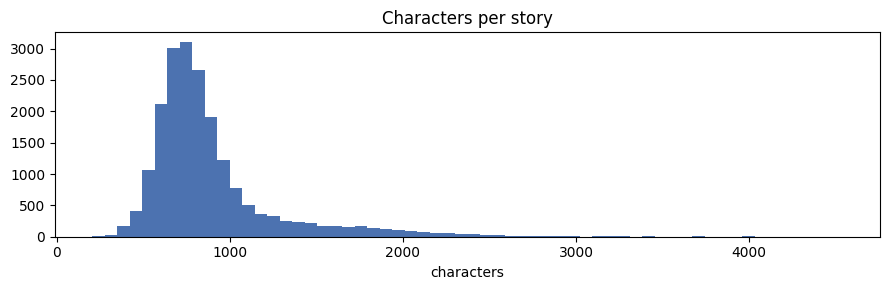

In [6]:
# 1.2 — Read your data. You cannot debug a model whose training data you have never read.

for i in range(2):
    print(f"--- Story {i} " + "-" * 58)
    print(raw["train"][i]["text"].strip()[:500], "\n")

lengths = np.array([len(t) for t in raw["train"].select(range(min(20_000, len(raw["train"]))))["text"]])
print("=" * 72)
print(f"Characters per story: mean {lengths.mean():.0f} | median {np.median(lengths):.0f} | p95 {np.percentile(lengths,95):.0f}")
print(f"Estimated corpus size: {lengths.mean()*len(raw['train'])/1e6:.1f} M characters")

plt.figure(figsize=(9, 3))
plt.hist(lengths, bins=60, color="#4C72B0")
plt.title("Characters per story"); plt.xlabel("characters"); plt.tight_layout(); plt.show()

In [7]:
# 1.3 — Clean and normalize.
# Every artifact you leave in the data is something the model must spend
# capacity learning to reproduce. At 27M parameters you have none to spare.

import unicodedata, re

_WS      = re.compile(r"[ \t]+")
_NL      = re.compile(r"\n{3,}")
_NONASCII = re.compile(r"[^\x20-\x7E\n]")
_SUBS = [("\u201c", '"'), ("\u201d", '"'), ("\u2018", "'"), ("\u2019", "'"),
         ("\u2013", "-"), ("\u2014", "-"), ("\u2026", "..."), ("\u00a0", " ")]

def clean(text):
    text = unicodedata.normalize("NFKC", text)
    for a, b in _SUBS:
        text = text.replace(a, b)
    text = _NONASCII.sub("", text)
    return _NL.sub("\n\n", _WS.sub(" ", text)).strip()

ds = raw.map(lambda b: {"text": [clean(t) for t in b["text"]]},
             batched=True, batch_size=2000, desc="cleaning")

before = len(ds["train"])
ds = ds.filter(lambda b: [len(t) >= 100 for t in b["text"]],
               batched=True, batch_size=2000, desc="filtering")

print(f"Dropped {before - len(ds['train']):,} stories under 100 chars")
print(f"Final: {len(ds['train']):,} train | {len(ds['validation']):,} validation")
print(f"\nSample:\n{ds['train'][0]['text'][:300]}")

cleaning:   0%|          | 0/2119719 [00:00<?, ? examples/s]

cleaning:   0%|          | 0/21990 [00:00<?, ? examples/s]

filtering:   0%|          | 0/2119719 [00:00<?, ? examples/s]

filtering:   0%|          | 0/21990 [00:00<?, ? examples/s]

Dropped 243 stories under 100 chars
Final: 2,119,476 train | 21,989 validation

Sample:
One day, a little girl named Lily found a needle in her room. She knew it was difficult to play with it because it was sharp. Lily wanted to share the needle with her mom, so she could sew a button on her shirt.

Lily went to her mom and said, "Mom, I found this needle. Can you share it with me and 


---
# Part 2 - Tokenization

## Why not just borrow GPT-2's tokenizer?

Because its vocabulary is 50,257 tokens built for the entire internet. Our corpus is children's stories. That embedding table would be `50,257 × 512 = 25.7M` parameters — larger than the rest of the model combined — and most of those rows would never receive a single gradient update, because those tokens never appear in our data.

Training our own BPE tokenizer at **8,192 tokens** gives an embedding table of `8,192 × 512 = 4.2M` instead, and a much cheaper output softmax. That is the difference between comfortably fitting on a T4 and not.

## Wrapping it for the ecosystem

We train the tokenizer with the `tokenizers` library, then **wrap it in `PreTrainedTokenizerFast`**. That wrapper is what buys us the rest of the notebook: it makes the tokenizer work with `Trainer`, with `model.generate()`, with `pipeline()` and with `save_pretrained()`. One wrapping step, and everything downstream just connects.

In [8]:
# 2.1 — Train a byte-level BPE tokenizer, then wrap it for the transformers ecosystem.

from tokenizers import Tokenizer, models, trainers, pre_tokenizers, decoders, processors
from transformers import PreTrainedTokenizerFast

VOCAB_SIZE = 8192
EOS_TOKEN, PAD_TOKEN = "<|endoftext|>", "<|pad|>"

backend = Tokenizer(models.BPE(unk_token=None))
backend.pre_tokenizer   = pre_tokenizers.ByteLevel(add_prefix_space=True)
backend.decoder         = decoders.ByteLevel()
backend.post_processor  = processors.ByteLevel(trim_offsets=True)

trainer_bpe = trainers.BpeTrainer(
    vocab_size=VOCAB_SIZE,
    special_tokens=[EOS_TOKEN, PAD_TOKEN],          # -> ids 0 and 1
    initial_alphabet=pre_tokenizers.ByteLevel.alphabet(),
    min_frequency=2,
    show_progress=True,
)

def text_iter(dset, bs=1000):
    for i in range(0, len(dset), bs):
        yield dset[i:i+bs]["text"]

print("Training BPE tokenizer...")
t0 = time.time()
backend.train_from_iterator(text_iter(ds["train"]), trainer=trainer_bpe, length=len(ds["train"]))
print(f"Done in {time.time()-t0:.1f}s")

# ---- The wrapper that connects everything downstream --------------------
tokenizer = PreTrainedTokenizerFast(
    tokenizer_object=backend,
    bos_token=EOS_TOKEN,
    eos_token=EOS_TOKEN,
    pad_token=PAD_TOKEN,
    unk_token=None,
    # Critical for BPE: the cleanup step is designed for WordPiece and will
    # strip spaces before punctuation, corrupting your decoded output.
    clean_up_tokenization_spaces=False,
)
tokenizer.save_pretrained(TOKENIZER_DIR)

EOS_ID, PAD_ID = tokenizer.eos_token_id, tokenizer.pad_token_id
print(f"\nVocab size: {len(tokenizer):,} | EOS id: {EOS_ID} | PAD id: {PAD_ID}")
print(f"Saved to  : {TOKENIZER_DIR}")

Training BPE tokenizer...
Done in 125.9s

Vocab size: 8,192 | EOS id: 0 | PAD id: 1
Saved to  : /content/drive/MyDrive/my_slm_hf/tokenizer


In [9]:
# 2.2 — Sanity checks. Roundtrip must be exact; compression should beat GPT-2's ~4.0.

tests = [
    "Once upon a time, there was a little girl named Lily.",
    "Antidisestablishmentarianism is a very long word.",
    "She said, \"Hello!\" and smiled.",
]
print(f"{'text':<54} {'tokens':>7} {'chars/tok':>10} {'roundtrip':>10}")
print("-" * 85)
for t in tests:
    ids = tokenizer(t, add_special_tokens=False)["input_ids"]
    ok = tokenizer.decode(ids).strip() == t.strip()
    print(f"{t[:52]:<54} {len(ids):>7} {len(t)/len(ids):>10.2f} {str(ok):>10}")

print("\nRare word splits into reusable pieces:")
print(tokenizer.tokenize("Antidisestablishmentarianism"))
print("\nCommon sentence stays mostly whole:")
print(tokenizer.tokenize("Once upon a time, there was a little girl."))

probe = list(ds["train"].select(range(min(2000, len(ds["train"]))))["text"])   # list() -- datasets v4+ returns a lazy Column
n_chars = sum(len(t) for t in probe)
n_toks  = sum(len(x) for x in tokenizer(probe, add_special_tokens=False)["input_ids"])
print(f"\nCorpus compression: {n_chars/n_toks:.2f} chars/token  (GPT-2 averages ~4.0)")

text                                                    tokens  chars/tok  roundtrip
-------------------------------------------------------------------------------------
Once upon a time, there was a little girl named Lily        13       4.08       True
Antidisestablishmentarianism is a very long word.           18       2.72       True
She said, "Hello!" and smiled.                               9       3.33       True

Rare word splits into reusable pieces:
['ĠA', 'nt', 'id', 'is', 'est', 'ab', 'l', 'ish', 'ment', 'arian', 'is', 'm']

Common sentence stays mostly whole:
['ĠOnce', 'Ġupon', 'Ġa', 'Ġtime', ',', 'Ġthere', 'Ġwas', 'Ġa', 'Ġlittle', 'Ġgirl', '.']

Corpus compression: 4.15 chars/token  (GPT-2 averages ~4.0)


## 2.3 Tokenize and pack into fixed-length blocks

Here we use the standard `datasets` idiom:

1. **Tokenize** every story, appending `EOS` so the model learns where documents end
2. **Concatenate** everything into one long stream
3. **Chunk** that stream into fixed `block_size` blocks

Step 3 is the important one. Padding each story to a fixed length would waste an enormous fraction of every batch on `<pad>` tokens. Packing means **every token in every batch is real training signal**. The model learns to read across document boundaries, which is fine — that is exactly how GPT-2, Llama and everything else is pretrained.

The result is cached to disk by `datasets`, so re-running is instant.

In [10]:
# 2.3 — Tokenize, concatenate, and chunk into training blocks.

BLOCK_SIZE = 512
os.environ["TOKENIZERS_PARALLELISM"] = "true"

def tokenize_fn(batch):
    out = tokenizer(batch["text"], add_special_tokens=False)["input_ids"]
    return {"input_ids": [ids + [EOS_ID] for ids in out]}

tokenized = ds.map(tokenize_fn, batched=True, batch_size=1000,
                   remove_columns=ds["train"].column_names, desc="tokenizing")

def group_texts(batch):
    # Flatten every story into one stream, then cut into equal blocks.
    stream = list(itertools.chain.from_iterable(batch["input_ids"]))
    n = (len(stream) // BLOCK_SIZE) * BLOCK_SIZE          # drop the ragged tail
    return {"input_ids": [stream[i:i+BLOCK_SIZE] for i in range(0, n, BLOCK_SIZE)]}

lm_ds = tokenized.map(group_texts, batched=True, batch_size=1000, desc="packing blocks")

n_train_tokens = len(lm_ds["train"]) * BLOCK_SIZE
print(lm_ds)
print(f"\nTrain blocks : {len(lm_ds['train']):,}  ({n_train_tokens/1e6:.1f} M tokens)")
print(f"Val blocks   : {len(lm_ds['validation']):,}")
print(f"\nEvery block is exactly {BLOCK_SIZE} real tokens -- zero padding waste.")

tokenizing:   0%|          | 0/2119476 [00:00<?, ? examples/s]

tokenizing:   0%|          | 0/21989 [00:00<?, ? examples/s]

packing blocks:   0%|          | 0/2119476 [00:00<?, ? examples/s]

packing blocks:   0%|          | 0/21989 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['input_ids'],
        num_rows: 907353
    })
    validation: Dataset({
        features: ['input_ids'],
        num_rows: 9121
    })
})

Train blocks : 907,353  (464.6 M tokens)
Val blocks   : 9,121

Every block is exactly 512 real tokens -- zero padding waste.


In [11]:
# 2.4 — Verify a packed block decodes back to readable English.

block = lm_ds["train"][0]["input_ids"]
print(f"Block length: {len(block)} tokens\n")
print("--- Decoded " + "-" * 60)
print(tokenizer.decode(block[:220]))
print("\n(An <|endoftext|> mid-block is correct -- that is a document boundary.)")

Block length: 512 tokens

--- Decoded ------------------------------------------------------------
 One day, a little girl named Lily found a needle in her room. She knew it was difficult to play with it because it was sharp. Lily wanted to share the needle with her mom, so she could sew a button on her shirt.

Lily went to her mom and said, "Mom, I found this needle. Can you share it with me and sew my shirt?" Her mom smiled and said, "Yes, Lily, we can share the needle and fix your shirt."

Together, they shared the needle and sewed the button on Lily's shirt. It was not difficult for them because they were sharing and helping each other. After they finished, Lily thanked her mom for sharing the needle and fixing her shirt. They both felt happy because they had shared and worked together.<|endoftext|> Once upon a time, there was a little car named Beep. Beep loved to go fast and play in the sun. Beep was a healthy car because he always had good fuel. Good fuel made Beep happy and str

---
# Part 3 - Building the Model


| Design choice | Config field |
|---|---|
| Decoder-only Transformer | `LlamaForCausalLM` |
| Pre-norm **RMSNorm** | built into the Llama architecture |
| **RoPE** positional encoding | `rope_parameters={"rope_type": "default", "rope_theta": 10000.0}` |
| **SwiGLU** feed-forward | `hidden_act="silu"` + gated MLP |
| **Grouped-Query Attention** | `num_key_value_heads=2` vs `num_attention_heads=8` → 4× KV cache reduction |
| No biases | `attention_bias=False`, `mlp_bias=False` |
| Tied embeddings | `tie_word_embeddings=True` |
| Flash Attention | `attn_implementation="sdpa"` |

> **v5 gotcha:** `rope_theta` moved inside `rope_parameters`. Reading `config.rope_theta` now raises `AttributeError`. This trips up a lot of v4 code.

**We are building from a random initialization.** `LlamaForCausalLM(config)` — note: *not* `.from_pretrained()`. No downloaded weights. Every parameter starts random and is trained by you.

In [12]:
# 3.1 — Define the architecture and instantiate an UNTRAINED model.

from transformers import LlamaConfig, LlamaForCausalLM

config = LlamaConfig(
    vocab_size              = VOCAB_SIZE,
    hidden_size             = 512,      # d_model -- residual stream width
    intermediate_size       = 1408,     # SwiGLU hidden, ~= 8/3 * hidden_size
    num_hidden_layers       = 8,
    num_attention_heads     = 8,        # query heads
    num_key_value_heads     = 2,        # GQA -> 8/2 = 4x smaller KV cache
    max_position_embeddings = BLOCK_SIZE,
    hidden_act              = "silu",   # SwiGLU
    rms_norm_eps            = 1e-5,
    rope_parameters         = {"rope_type": "default", "rope_theta": 10000.0},
    tie_word_embeddings     = True,
    attention_bias          = False,
    mlp_bias                = False,
    initializer_range       = 0.02,
    bos_token_id            = EOS_ID,
    eos_token_id            = EOS_ID,
    pad_token_id            = PAD_ID,
    attn_implementation     = "sdpa",   # dispatches to Flash Attention on GPU
)

model = LlamaForCausalLM(config)        # NOT from_pretrained -- random weights
model = model.to(DEVICE)

total   = sum(p.numel() for p in model.parameters())
non_emb = total - model.model.embed_tokens.weight.numel()
print(f"Total parameters        : {total:,}  ({total/1e6:.2f} M)")
print(f"Non-embedding parameters: {non_emb:,}  ({non_emb/1e6:.2f} M)")
print(f"Size in fp16            : {total*2/1e6:.1f} MB")
print(f"\nAttention implementation: {model.config._attn_implementation}")

Total parameters        : 26,747,392  (26.75 M)
Non-embedding parameters: 22,553,088  (22.55 M)
Size in fp16            : 53.5 MB

Attention implementation: sdpa


In [13]:
# 3.2 — Inspect the architecture. The abstraction is thin: you can see every
# component from the from-scratch notebook sitting right there.

print(model.model.layers[0])
print("\n" + "=" * 72)
print("Reading that output:")
print("  q_proj 512->512, k_proj/v_proj 512->128   <- GQA (2 KV heads x 64 dim)")
print("  LlamaRMSNorm                              <- RMSNorm, applied pre-sublayer")
print("  gate_proj + up_proj + down_proj, SiLU     <- SwiGLU (3 matrices, not 2)")
print("  bias=False everywhere                     <- no bias terms")
print("  (RoPE is applied inside the attention forward, so it has no module here)")

LlamaDecoderLayer(
  (self_attn): LlamaAttention(
    (q_proj): Linear(in_features=512, out_features=512, bias=False)
    (k_proj): Linear(in_features=512, out_features=128, bias=False)
    (v_proj): Linear(in_features=512, out_features=128, bias=False)
    (o_proj): Linear(in_features=512, out_features=512, bias=False)
  )
  (mlp): LlamaMLP(
    (gate_proj): Linear(in_features=512, out_features=1408, bias=False)
    (up_proj): Linear(in_features=512, out_features=1408, bias=False)
    (down_proj): Linear(in_features=1408, out_features=512, bias=False)
    (act_fn): SiLUActivation()
  )
  (input_layernorm): LlamaRMSNorm((512,), eps=1e-05)
  (post_attention_layernorm): LlamaRMSNorm((512,), eps=1e-05)
)

Reading that output:
  q_proj 512->512, k_proj/v_proj 512->128   <- GQA (2 KV heads x 64 dim)
  LlamaRMSNorm                              <- RMSNorm, applied pre-sublayer
  gate_proj + up_proj + down_proj, SiLU     <- SwiGLU (3 matrices, not 2)
  bias=False everywhere                    

In [14]:
# 3.3 — Parameter budget: where is the capacity actually going?

groups = {}
for name, p in model.named_parameters():
    if "embed_tokens" in name:                           k = "Token embedding (tied with lm_head)"
    elif any(s in name for s in ("q_proj","k_proj","v_proj","o_proj")): k = "Attention (GQA)"
    elif any(s in name for s in ("gate_proj","up_proj","down_proj")):   k = "Feed-forward (SwiGLU)"
    else:                                                k = "Norms"
    groups[k] = groups.get(k, 0) + p.numel()

print(f"{'Component':<42} {'Params':>12} {'Share':>8}")
print("-" * 64)
for k, v in sorted(groups.items(), key=lambda kv: -kv[1]):
    print(f"{k:<42} {v:>12,} {v/total*100:>7.1f}%")
print("-" * 64)
print(f"{'TOTAL':<42} {total:>12,} {100.0:>7.1f}%")

Component                                        Params    Share
----------------------------------------------------------------
Feed-forward (SwiGLU)                        17,301,504    64.7%
Attention (GQA)                               5,242,880    19.6%
Token embedding (tied with lm_head)           4,194,304    15.7%
Norms                                             8,704     0.0%
----------------------------------------------------------------
TOTAL                                        26,747,392   100.0%


In [15]:
# 3.4 — Initialization sanity check.
# An untrained model should be MAXIMALLY uncertain: loss == ln(vocab_size).
# If this fails, something is wrong before you waste hours training.

model.eval()
ids = torch.randint(0, VOCAB_SIZE, (2, 64), device=DEVICE)
with torch.no_grad():
    loss = model(input_ids=ids, labels=ids).loss.item()

expected = math.log(VOCAB_SIZE)
print(f"Initial loss : {loss:.4f}")
print(f"ln(vocab)    : {expected:.4f}")
print(f"Difference   : {abs(loss-expected):.4f}\n")
print("PASS" if abs(loss - expected) < 0.5 else "FAIL -- check initializer_range")

Initial loss : 9.0908
ln(vocab)    : 9.0109
Difference   : 0.0799

PASS


---
# Part 4 - Training

A hand-written training loop is about 60 lines — batching, mixed precision, gradient accumulation, clipping, scheduling, checkpointing. Here it collapses into a `TrainingArguments` object and one `trainer.train()` call.

None of those techniques disappeared. They moved from code you write into flags you set:

| Technique | Where it lives now |
|---|---|
| Mixed precision (bf16/fp16) | `bf16=` / `fp16=` |
| Gradient accumulation | `gradient_accumulation_steps=` |
| Cosine schedule + warmup | `lr_scheduler_type="cosine"`, `warmup_steps=` |
| Gradient clipping | `max_grad_norm=1.0` |
| Fused AdamW | `optim="adamw_torch_fused"` |
| Periodic eval + checkpointing | `eval_strategy` / `save_strategy` |
| Keeping the best model | `load_best_model_at_end=True` |
| Resume after a crash | `resume_from_checkpoint=True` |

**Weight decay note:** `Trainer` already excludes biases and `LayerNorm`/`RMSNorm` parameters from weight decay automatically. Written by hand, you would have to build those parameter groups yourself.

> **v5 gotchas in this cell:** `eval_strategy` (not `evaluation_strategy`), and `Trainer(processing_class=...)` (not `tokenizer=`).

In [16]:
# 4.1 — Training arguments.

from transformers import TrainingArguments, Trainer, DataCollatorForLanguageModeling

BATCH_SIZE  = 24    # lower this FIRST if you hit OOM
GRAD_ACCUM  = 3     # ...and raise this to keep the effective batch identical
MAX_STEPS   = 4000 if USE_SUBSET else 12000

args = TrainingArguments(
    output_dir                  = CKPT_DIR,

    # --- batch / schedule -------------------------------------------------
    per_device_train_batch_size = BATCH_SIZE,
    per_device_eval_batch_size  = BATCH_SIZE,
    gradient_accumulation_steps = GRAD_ACCUM,
    max_steps                   = MAX_STEPS,

    # --- optimizer --------------------------------------------------------
    learning_rate               = 6e-4,
    lr_scheduler_type           = "cosine",
    warmup_steps                = 200,
    weight_decay                = 0.1,     # auto-excludes norms and biases
    adam_beta1                  = 0.9,
    adam_beta2                  = 0.95,    # 0.95, not the 0.999 default -- LM convention
    max_grad_norm               = 1.0,
    optim                       = "adamw_torch_fused",

    # --- precision --------------------------------------------------------
    bf16                        = USE_BF16,
    fp16                        = USE_FP16,

    # --- eval / checkpointing --------------------------------------------
    eval_strategy               = "steps",   # v5: renamed from evaluation_strategy
    eval_steps                  = 250,
    save_strategy               = "steps",
    save_steps                  = 250,
    save_total_limit            = 3,         # Drive has finite space
    load_best_model_at_end      = True,
    metric_for_best_model       = "eval_loss",
    greater_is_better           = False,

    # --- logging ----------------------------------------------------------
    logging_steps               = 20,
    report_to                   = "none",    # set "tensorboard" or "wandb" if you like
    seed                        = SEED,
    dataloader_num_workers      = 2,
    dataloader_pin_memory       = True,
)

eff = BATCH_SIZE * GRAD_ACCUM
print(f"Effective batch : {eff} sequences ({eff * BLOCK_SIZE:,} tokens/step)")
print(f"Total steps     : {MAX_STEPS:,}")
print(f"Tokens seen     : {eff * BLOCK_SIZE * MAX_STEPS / 1e6:.1f} M")
print(f"Epochs          : {eff * BLOCK_SIZE * MAX_STEPS / n_train_tokens:.2f}")

Effective batch : 72 sequences (36,864 tokens/step)
Total steps     : 12,000
Tokens seen     : 442.4 M
Epochs          : 0.95


In [17]:
# 4.2 — Data collator and a callback that shows you real samples during training.

# mlm=False -> causal LM. The collator builds `labels` from `input_ids` and the
# model handles the one-position shift internally. No manual x/y slicing.
collator = DataCollatorForLanguageModeling(tokenizer=tokenizer, mlm=False)

from transformers import TrainerCallback

class SampleCallback(TrainerCallback):
    # Loss numbers tell you the model is learning. Samples tell you WHAT it learned.
    def __init__(self, tok, prompt="Once upon a time", every=500, n_tokens=80):
        self.tok, self.prompt, self.every, self.n = tok, prompt, every, n_tokens

    def on_step_end(self, args, state, control, model=None, **kw):
        if state.global_step % self.every != 0 or state.global_step == 0:
            return
        model.eval()
        enc = self.tok(self.prompt, return_tensors="pt").to(model.device)
        with torch.no_grad():
            out = model.generate(**enc, max_new_tokens=self.n, do_sample=True,
                                 temperature=0.8, top_p=0.9,
                                 pad_token_id=self.tok.pad_token_id)
        print(f"\n--- sample @ step {state.global_step} " + "-" * 40)
        print(self.tok.decode(out[0], skip_special_tokens=True))
        print("-" * 62 + "\n")
        model.train()

trainer = Trainer(
    model            = model,
    args             = args,
    train_dataset    = lm_ds["train"],
    eval_dataset     = lm_ds["validation"],
    data_collator    = collator,
    processing_class = tokenizer,          # v5: renamed from tokenizer=
    callbacks        = [SampleCallback(tokenizer)],
)
print("Trainer ready.")

Trainer ready.


## 4.3 When you hit `CUDA out of memory`

Work down this list in order. The first two cost you **nothing** in final model quality.

| Fix | How | Cost |
|---|---|---|
| **1. Smaller micro-batch, more accumulation** | `per_device_train_batch_size=12, gradient_accumulation_steps=6` | None — effective batch unchanged |
| **2. Restart the runtime** | `Runtime → Restart runtime` | Clears fragmented VRAM |
| **3. Gradient checkpointing** | `gradient_checkpointing=True` | ~30% slower, ~40% less activation memory |
| **4. Shorter context** | `BLOCK_SIZE = 256` | Model sees less context |
| **5. Smaller model** | `num_hidden_layers=6, hidden_size=384` | Lower capacity |

**Two things that catch everyone:**

- **`torch.cuda.empty_cache()` will not save you.** It frees *cached* blocks, not *allocated* ones. If peak allocation exceeds VRAM, only a smaller batch helps.
- **Fragmentation is real.** After several cells that allocated large tensors, restarting the runtime often frees more than any code change.

Beginners reflexively reach for #5. It is the worst option on the list — reach for #1.

In [18]:
# 4.3 — Low-memory configuration. Use this if the standard settings OOM.
# Effective batch stays at 72 sequences, so training dynamics are unchanged.

LOW_MEMORY = False

if LOW_MEMORY:
    args.per_device_train_batch_size = 8
    args.per_device_eval_batch_size  = 8
    args.gradient_accumulation_steps = 9      # 8 x 9 = 72, same as 24 x 3
    args.gradient_checkpointing      = True
    model.config.use_cache = False            # required with checkpointing
    print("Low-memory mode ON")
    print(f"  micro-batch {args.per_device_train_batch_size} x accum {args.gradient_accumulation_steps} "
          f"= {args.per_device_train_batch_size * args.gradient_accumulation_steps} effective")
    print("  Re-create the Trainer (cell 4.2) after changing these.")
else:
    print("Standard memory mode. Set LOW_MEMORY = True if you hit OOM.")

Standard memory mode. Set LOW_MEMORY = True if you hit OOM.


### 4.4 Train

What to expect:

- Loss starts near **9.0** (`ln(8192)`) and drops below 4.0 within a few hundred steps, then grinds slowly toward **1.5–2.5**
- Below ~2.0 on TinyStories you get genuinely readable stories
- **Watch `eval_loss`, not `loss`.** Training loss always falls; validation loss falling is what means the model is learning something generalizable
- The `SampleCallback` prints real generated text every 500 steps so you can watch grammar emerge

**If Colab disconnects:** re-run cells 0.1–0.4, then 2.1 (loads the saved tokenizer), 2.3, 3.1, 4.1, 4.2, and run cell 4.4 with `RESUME = True`. That one flag makes `Trainer` find the latest checkpoint in `output_dir` and restore model, optimizer, scheduler and step count.

In [19]:
# 4.4 - Train.

RESUME = True   # picks up the latest checkpoint in CKPT_DIR if one exists

has_ckpt = any(d.startswith("checkpoint-") for d in os.listdir(CKPT_DIR)) if os.path.exists(CKPT_DIR) else False
print(f"Existing checkpoint found: {has_ckpt}")

t0 = time.time()
result = trainer.train(resume_from_checkpoint=(RESUME and has_ckpt))
mins = (time.time() - t0) / 60

print(f"\nTraining finished in {mins:.1f} minutes")
print(f"Final training loss: {result.training_loss:.4f}")

metrics = trainer.evaluate()
print(f"Final eval loss    : {metrics['eval_loss']:.4f}")
print(f"Final perplexity   : {math.exp(metrics['eval_loss']):.2f}")

Existing checkpoint found: True


[transformers] There were missing keys in the checkpoint model loaded: ['lm_head.weight'].


Step,Training Loss,Validation Loss
12001,1.427421,1.414838


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

[transformers] There were missing keys in the checkpoint model loaded: ['lm_head.weight'].



Training finished in 0.4 minutes
Final training loss: 0.0001


Training Loss,Validation Loss,Step
1.427421,1.414838,12001


Final eval loss    : 1.4148
Final perplexity   : 4.12


---
# Part 5 — Training on Free Cloud GPUs

## Where your VRAM actually goes

| Consumer | Approx size | Scales with |
|---|---|---|
| Model weights | ~107 MB (fp32) | parameters |
| Gradients | ~107 MB | parameters |
| AdamW state (2 moments) | ~214 MB | parameters |
| **Activations** | **~2–6 GB** | `batch_size × block_size × hidden × layers` |

Note the asymmetry. A 27M model needs under 500 MB for weights and optimizer state. **Activations dominate**, and activations are controlled by `per_device_train_batch_size`. That is why it is always the first dial to turn.

In [20]:
# 5.1 — Memory report.

def memory_report():
    if DEVICE != "cuda":
        print("CPU mode."); return
    tot  = torch.cuda.get_device_properties(0).total_memory / 1e9
    peak = torch.cuda.max_memory_allocated() / 1e9
    print(f"Total VRAM        : {tot:6.2f} GB")
    print(f"Currently allocated: {torch.cuda.memory_allocated()/1e9:6.2f} GB")
    print(f"Reserved by torch  : {torch.cuda.memory_reserved()/1e9:6.2f} GB")
    print(f"Peak allocated     : {peak:6.2f} GB  <- the number that matters")
    bar = int(30 * peak / tot)
    print(f"\n[{'#'*bar}{'.'*(30-bar)}] {100*peak/tot:.0f}% peak")

memory_report()

Total VRAM        :  42.41 GB
Currently allocated:   0.35 GB
Reserved by torch  :   4.63 GB
Peak allocated     :   4.49 GB  <- the number that matters

[###...........................] 11% peak


## 5.2 Surviving Colab sessions

**Keep the tab alive.** Browser console (`F12` → Console):

```javascript
setInterval(() => {
  document.querySelector("colab-toolbar-button#connect")?.click();
  console.log("ping", new Date().toLocaleTimeString());
}, 60000);
```

**Assume it dies anyway**:

```python
trainer.train(resume_from_checkpoint=True)
```

`Trainer` writes a full checkpoint — model, optimizer, LR scheduler, RNG state, step counter — to `output_dir` every `save_steps`. On resume it restores all of it and continues as if nothing happened. `save_total_limit=3` keeps Drive from filling up.

In [21]:
# 5.2 — Restore everything from Drive after a disconnect.

def restore_from_drive():
    from transformers import AutoTokenizer, AutoModelForCausalLM
    ckpts = sorted(
        [d for d in os.listdir(CKPT_DIR) if d.startswith("checkpoint-")],
        key=lambda d: int(d.split("-")[1]),
    )
    if not ckpts:
        print("No checkpoints found."); return None, None
    latest = os.path.join(CKPT_DIR, ckpts[-1])
    tok = AutoTokenizer.from_pretrained(TOKENIZER_DIR)
    mdl = AutoModelForCausalLM.from_pretrained(latest).to(DEVICE)
    print(f"Restored from : {ckpts[-1]}")
    print(f"Parameters    : {sum(p.numel() for p in mdl.parameters()):,}")
    print(f"All checkpoints: {ckpts}")
    return mdl, tok

print("Call restore_from_drive() after a disconnect:")
print("  model, tokenizer = restore_from_drive()")

Call restore_from_drive() after a disconnect:
  model, tokenizer = restore_from_drive()


---
# Part 6 - Evaluating Your Model

Three lenses, in increasing order of what they actually tell you:

1. **Loss curves** — is it learning, and is it overfitting?
2. **Perplexity** — one interpretable number for prediction quality
3. **Generated samples** — the only test that truly matters

Number 3 is not optional. A model can post a perfectly respectable perplexity and still produce garbage. **Read the output.**

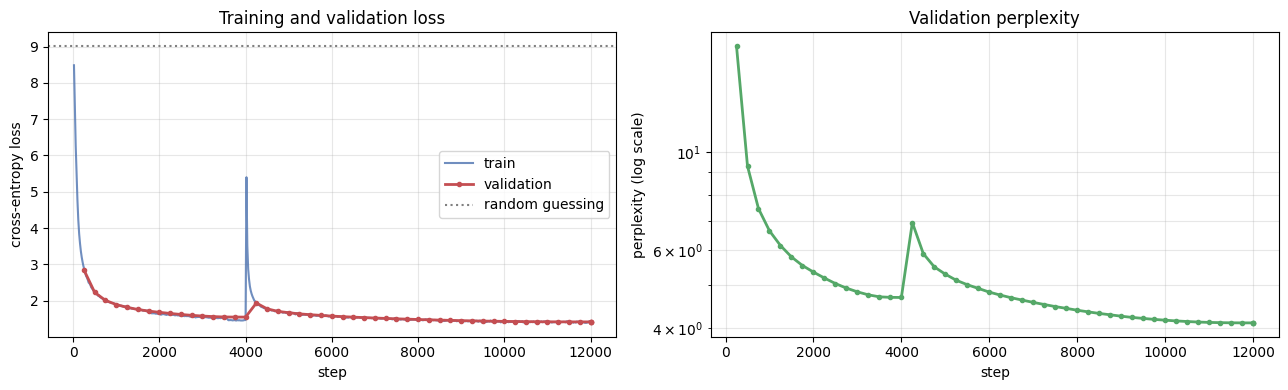

Final train 1.4274 | eval 1.4148 | gap -0.0126

DIAGNOSIS: Healthy. Train and eval are close and both low.


In [22]:
# 6.1 — Loss curves from trainer.state.log_history.

log = trainer.state.log_history
train_pts = [(e["step"], e["loss"])      for e in log if "loss"      in e]
eval_pts  = [(e["step"], e["eval_loss"]) for e in log if "eval_loss" in e]

fig, ax = plt.subplots(1, 2, figsize=(13, 4))
ax[0].plot(*zip(*train_pts), label="train", lw=1.5, alpha=.8, color="#4C72B0")
if eval_pts:
    ax[0].plot(*zip(*eval_pts), label="validation", lw=2, marker="o", ms=3, color="#C44E52")
ax[0].axhline(math.log(VOCAB_SIZE), ls=":", c="gray", label="random guessing")
ax[0].set_xlabel("step"); ax[0].set_ylabel("cross-entropy loss")
ax[0].set_title("Training and validation loss"); ax[0].legend(); ax[0].grid(alpha=.3)

if eval_pts:
    steps, losses = zip(*eval_pts)
    ax[1].plot(steps, [math.exp(l) for l in losses], lw=2, marker="o", ms=3, color="#55A868")
    ax[1].set_yscale("log")
ax[1].set_xlabel("step"); ax[1].set_ylabel("perplexity (log scale)")
ax[1].set_title("Validation perplexity"); ax[1].grid(alpha=.3, which="both")
plt.tight_layout(); plt.show()

if eval_pts and train_pts:
    gap = eval_pts[-1][1] - train_pts[-1][1]
    print(f"Final train {train_pts[-1][1]:.4f} | eval {eval_pts[-1][1]:.4f} | gap {gap:+.4f}\n")
    if gap > 0.20:
        print("DIAGNOSIS: Overfitting -> more data, or stop earlier.")
    elif eval_pts[-1][1] > 3.0:
        print("DIAGNOSIS: Underfitting -> train longer, or add capacity.")
    else:
        print("DIAGNOSIS: Healthy. Train and eval are close and both low.")

In [23]:
# 6.2 — Perplexity.

metrics = trainer.evaluate()
ppl = math.exp(metrics["eval_loss"])
print(f"Eval loss  : {metrics['eval_loss']:.4f}")
print(f"Perplexity : {ppl:.2f}\n")
print("Interpreting perplexity on TinyStories:")
for lo, hi, label in [(100, 1e9, "barely learned anything"),
                      (30, 100, "grammatical but incoherent"),
                      (10, 30,  "readable, mostly coherent   <-- realistic target"),
                      (0,  10,  "excellent (full corpus + long training)")]:
    mark = "  <<< YOU ARE HERE" if lo <= ppl < hi else ""
    rng = f"> {lo}" if hi > 1e8 else f"{lo}-{hi}"
    print(f"  {rng:<10} {label}{mark}")

Training Loss,Validation Loss,Step
1.427421,1.414838,12001


Eval loss  : 1.4148
Perplexity : 4.12

Interpreting perplexity on TinyStories:
  > 100      barely learned anything
  30-100     grammatical but incoherent
  10-30      readable, mostly coherent   <-- realistic target
  0-10       excellent (full corpus + long training)  <<< YOU ARE HERE


## 6.3 Generation and sampling strategies

`model.generate()` brings a **KV cache** for free (5–10× faster than recomputing attention over the full prefix at every step).

| Strategy | What it does | Arguments |
|---|---|---|
| **Greedy** | Always take the top token | `do_sample=False` |
| **Temperature** | `<1` sharpens, `>1` flattens the distribution | `temperature=0.8` |
| **Top-k** | Keep only the `k` most likely tokens | `top_k=50` |
| **Top-p (nucleus)** | Keep the smallest set summing to `p` | `top_p=0.9` |
| **Repetition penalty** | Down-weight already-used tokens | `repetition_penalty=1.15` |
| **Beam search** | Explore several sequences, keep the best | `num_beams=4` |

Sensible default: `temperature=0.8, top_p=0.9`.

In [24]:
# 6.3 — A reusable generation helper.

from transformers import GenerationConfig

@torch.no_grad()
def generate(prompt="Once upon a time", max_new_tokens=200, **kw):
    model.eval()
    gen_cfg = GenerationConfig(
        max_new_tokens     = max_new_tokens,
        do_sample          = kw.pop("do_sample", True),
        temperature        = kw.pop("temperature", 0.8),
        top_p              = kw.pop("top_p", 0.9),
        top_k              = kw.pop("top_k", 50),
        repetition_penalty = kw.pop("repetition_penalty", 1.0),
        eos_token_id       = EOS_ID,
        pad_token_id       = PAD_ID,
        **kw,
    )
    enc = tokenizer(prompt, return_tensors="pt").to(DEVICE)
    out = model.generate(**enc, generation_config=gen_cfg)
    return tokenizer.decode(out[0], skip_special_tokens=True)

print("=" * 78)
print("FIRST SAMPLE FROM YOUR MODEL")
print("=" * 78)
print(generate("Once upon a time", max_new_tokens=200))

FIRST SAMPLE FROM YOUR MODEL
 Once upon a time, there was a little girl named Lily. She loved to play with her toys and sing songs. One day, she went to the park with her mom and saw a big, round ball. It was so big that she could barely fit in it.

Lily's mom said, "Do you want to play with the ball, Lily?" Lily was so excited and said, "Yes, please!" They played with the ball for a while, but then Lily got bored. She wanted to play something else.

She saw a tree and asked her mom, "Can we swing on the tree?" Her mom said, "Sure, let's go!" They swung back and forth, laughing and having fun. Lily was so happy that she didn't want to leave the park.

After a while, it was time to go home. Lily was sad, but she said, "I had so much fun today, Mommy. Can we come back to the park tomorrow?" Her


In [25]:
# 6.4 — Compare sampling strategies on one prompt.

PROMPT = "Once upon a time, there was a little girl named Lily who"

strategies = [
    ("Greedy",                   dict(do_sample=False)),
    ("Low temperature (0.5)",    dict(temperature=0.5)),
    ("Balanced (0.8 + top_p .9)",dict(temperature=0.8, top_p=0.9)),
    ("Top-k 40",                 dict(temperature=0.8, top_k=40, top_p=1.0)),
    ("High temperature (1.3)",   dict(temperature=1.3)),
    ("Repetition penalty 1.15",  dict(temperature=0.8, top_p=0.9, repetition_penalty=1.15)),
    ("Beam search (4 beams)",    dict(do_sample=False, num_beams=4)),
]

for label, kw in strategies:
    print("=" * 78)
    print(label)
    print("-" * 78)
    print(generate(PROMPT, max_new_tokens=130, **kw))
    print()

[transformers] The following generation flags are not valid and may be ignored: ['temperature', 'top_p']. Set `TRANSFORMERS_VERBOSITY=info` for more details.


Greedy
------------------------------------------------------------------------------
 Once upon a time, there was a little girl named Lily who loved to play outside. One day, she went to the park with her mom and saw a big, red ball. She wanted to play with it, but her mom said no because it was too big for her.

Lily was sad, but then she saw a boy playing with a ball. She asked him if she could play too, but he said no. Lily felt sad and didn't know what to do. She went to her mom and said, "Mommy, I want to play with the ball, but I don't know how to play with it."

Her mom said, "Don't worry, Lily. You

Low temperature (0.5)
------------------------------------------------------------------------------
 Once upon a time, there was a little girl named Lily who loved to play with her toys. One day, she went to the park with her mommy and daddy. They brought a big bag of popcorn to share.

Lily was so excited to eat the popcorn, but she accidentally dropped it on the ground. She was 

In [26]:
# 6.5 — Several prompts, to check the model generalizes rather than memorizes.

prompts = [
    "Once upon a time",
    "Tom and Sara were playing in the garden when they found",
    "The little cat was very hungry, so she",
    "One day, a big dog saw a",
    "Lily wanted to help her mom, so she",
]
for i, p in enumerate(prompts):
    print("=" * 78)
    print(f"PROMPT {i+1}: {p}")
    print("-" * 78)
    print(generate(p, max_new_tokens=170, temperature=0.8, top_p=0.9))
    print()

PROMPT 1: Once upon a time
------------------------------------------------------------------------------
 Once upon a time, there was a little girl named Lily. She loved to play outside and get dirty. One day, her mom said, "Lily, it's time to take a bath." Lily didn't want to take a bath because she was having so much fun. 

Her mom said, "Lily, you need to take a bath so you can be clean and healthy." 

Lily didn't want to take a bath because she was having too much fun. But her mom said, "If you don't take a bath, you'll be in trouble." 

Lily thought about it and decided to take a bath. After the bath, she felt clean and happy. She thanked her mom for the bath and promised to take a bath every day.

PROMPT 2: Tom and Sara were playing in the garden when they found
------------------------------------------------------------------------------
 Tom and Sara were playing in the garden when they found a big, shiny rock. They both wanted to keep it, but they started to quarrel.

"I saw

In [27]:
# 6.6 — Save the finished model in standard Hugging Face format.
# This layout loads anywhere with AutoModelForCausalLM.from_pretrained(FINAL_DIR).

model.save_pretrained(FINAL_DIR)         # safetensors only in v5
tokenizer.save_pretrained(FINAL_DIR)

GenerationConfig(
    max_new_tokens=200,
    max_length=BLOCK_SIZE,               # override the unhelpful default of 20
    do_sample=True, temperature=0.8, top_p=0.9,
    repetition_penalty=1.1, eos_token_id=EOS_ID, pad_token_id=PAD_ID,
).save_pretrained(FINAL_DIR)             # good defaults travel with the model

print(f"Saved to {FINAL_DIR}:")
for fn in sorted(os.listdir(FINAL_DIR)):
    print(f"  {fn:<28} {os.path.getsize(os.path.join(FINAL_DIR, fn))/1e6:8.2f} MB")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Saved to /content/drive/MyDrive/my_slm_hf/final_model:
  config.json                      0.00 MB
  generation_config.json           0.00 MB
  model.safetensors              107.00 MB
  tokenizer.json                   0.55 MB
  tokenizer_config.json            0.00 MB


In [28]:
# 6.7 — Reload from disk and use it through a pipeline, exactly as an end user would.

from transformers import AutoTokenizer, AutoModelForCausalLM, pipeline

reloaded_tok   = AutoTokenizer.from_pretrained(FINAL_DIR)
reloaded_model = AutoModelForCausalLM.from_pretrained(FINAL_DIR).to(DEVICE)

storyteller = pipeline("text-generation", model=reloaded_model,
                       tokenizer=reloaded_tok, device=0 if DEVICE == "cuda" else -1)

# No sampling arguments needed -- generation_config.json travels with the model.
# (In v5, passing both a saved generation_config AND explicit kwargs is deprecated.)
out = storyteller("Once upon a time, a small rabbit")
print(out[0]["generated_text"])
print("\nYour model now behaves like any model on the Hub.")

Loading weights:   0%|          | 0/74 [00:00<?, ?it/s]

[transformers] Both `max_new_tokens` (=200) and `max_length`(=512) seem to have been set. `max_new_tokens` will take precedence. Please refer to the documentation for more information. (https://huggingface.co/docs/transformers/main/en/main_classes/text_generation)
[transformers] Ignoring clean_up_tokenization_spaces=True for BPE tokenizer TokenizersBackend. The clean_up_tokenization post-processing step is designed for WordPiece tokenizers and is destructive for BPE (it strips spaces before punctuation). Set clean_up_tokenization_spaces=False to suppress this warning, or set clean_up_tokenization_spaces_for_bpe_even_though_it_will_corrupt_output=True to force cleanup anyway.


Once upon a time, a small rabbit named Benny was hopping around in the forest. He saw a big tree and wanted to climb it. But he was too small to jump high enough to reach the top.

Suddenly, he heard a loud noise coming from below him. It was a bird who was stuck on the roof of a nearby house. Benny knew he had to help the bird. He hopped over to the roof and gently helped the bird get down. The bird was so happy that it flew away.

Benny felt proud that he could help the bird. He learned that sometimes we need to be brave and help others, even if we don't know how to do something. And that's the moral of the story: it's always good to ask for help when you need it.

Your model now behaves like any model on the Hub.


In [29]:
# 6.8 — OPTIONAL: a shareable Gradio demo.
# Make BUILD_DEMO = True while building.

BUILD_DEMO = False

if BUILD_DEMO:
    !pip install -q gradio
    import gradio as gr

    def infer(prompt, n, temp, top_p, rep):
        return generate(prompt or "Once upon a time", max_new_tokens=int(n),
                        temperature=float(temp), top_p=float(top_p),
                        repetition_penalty=float(rep))

    gr.Interface(
        fn=infer,
        inputs=[gr.Textbox(label="Prompt", value="Once upon a time"),
                gr.Slider(20, 400, value=200, step=10, label="Max new tokens"),
                gr.Slider(0.1, 1.5, value=0.8, step=0.05, label="Temperature"),
                gr.Slider(0.1, 1.0, value=0.9, step=0.05, label="Top-p"),
                gr.Slider(1.0, 2.0, value=1.1, step=0.05, label="Repetition penalty")],
        outputs=gr.Textbox(label="Generated story", lines=12),
        title="My Small Language Model",
        description="A ~27M parameter Llama-architecture model trained from scratch on TinyStories.",
    ).launch(share=True)
else:
    print("Set BUILD_DEMO = True to launch a public demo.")

Set BUILD_DEMO = True to launch a public demo.


---
# You trained a language model.

Every weight in that model started as a random number and was shaped entirely by your training run. You chose the architecture, built the tokenizer, prepared the data, and ran the optimization. Nothing was downloaded.

## Where to go next

**Train on the full corpus.** Set `USE_SUBSET = False` and re-run from cell 1.1. This is the single highest-leverage change available and costs only time.

**Scale up.** `hidden_size=768, num_hidden_layers=12, num_attention_heads=12, num_key_value_heads=4` is roughly 90M parameters — still trainable on a T4 with `LOW_MEMORY = True`.

**Change the data.** The pipeline is dataset-agnostic. Point Part 1 at a codebase, a set of papers, or your company's documentation.

**Try other architectures.** Swap `LlamaConfig` for `MistralConfig` (sliding-window attention), `Qwen3Config`, or `MixtralConfig` (Mixture-of-Experts). Same `Trainer`, same data, one line changed. This is the real payoff of using the library — architecture comparison becomes trivial.

_[FUTURE IMPLEMENTATION: **Add instruction tuning (a future part).** Right now the model completes text. To make it *follow instructions* you need supervised fine-tuning on prompt/response pairs — `trl`'s `SFTTrainer` picks up exactly where this notebook ends.]_

## The papers behind the config

| Config field | Paper |
|---|---|
| `LlamaForCausalLM` | *Attention Is All You Need* — Vaswani et al., 2017 (arXiv:1706.03762) |
| RMSNorm | Zhang & Sennrich, 2019 (arXiv:1910.07467) |
| `rope_parameters` | *RoFormer* — Su et al., 2021 (arXiv:2104.09864) |
| `hidden_act="silu"` | *GLU Variants Improve Transformer* — Shazeer, 2020 (arXiv:2002.05202) |
| `num_key_value_heads` | *GQA* — Ainslie et al., 2023 (arXiv:2305.13245) |
| `attn_implementation="sdpa"` | *FlashAttention* — Dao et al., 2022 (arXiv:2205.14135) |
| TinyStories | Eldan & Li, 2023 (arXiv:2305.07759) |